
# WDI Hackathon – Gelir Grupları Arasındaki Sağlık Uçurumu Analizi

Bu notebook, **CIRS Data Quest / WDI** temasına uygun olarak; ülkeleri gelir düzeylerine göre (K-Means ile) gruplandırıp
sağlık göstergelerindeki farklılıkları incelemek için hazırlandı. Aşağıdaki akış, 4 slaytlık sunum yapısına birebir uyumludur.


In [5]:

# ==============================
# 0) Kurulum ve Kütüphaneler
# ==============================
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Dosya yolları (yüklü dosyalar)
# Eğer dosyalar notebook ile aynı klasördeyse:
DATA_DIR = Path.cwd()

# Eğer dosyaları farklı klasöre koyduysan, tam yolu belirt:
# DATA_DIR = Path(r"C:\Users\musta\udemy_ML\Machine Learning\ytu_datath")

WDI_CSV = DATA_DIR / "WDICSV.csv"                # Ana veri (ülke x indikatör x yıllar geniş format)
WDI_COUNTRY = DATA_DIR / "WDICountry.csv"        # Ülke meta (IncomeGroup, Region vs.)
WDI_SERIES = DATA_DIR / "WDISeries.csv"          # Göstergelerin meta bilgileri
WDI_FOOTNOTE = DATA_DIR / "WDIfootnote.csv"      # (Opsiyonel) Dipnotlar
WDI_COUNTRY_SERIES = DATA_DIR / "WDIcountry-series.csv"  # (Opsiyonel) ülke-özel seri meta
WDI_SERIES_TIME = DATA_DIR / "WDIseries-time.csv"         # (Opsiyonel) zaman kapsamı

# Çıktı klasörü
FIG_DIR = Path.cwd() / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


print("Dosyalar mevcut mu?")
for p in [WDI_CSV, WDI_COUNTRY, WDI_SERIES]:
    print(p.name, "->", p.exists())
print("Çıktı klasörü:", FIG_DIR)


Dosyalar mevcut mu?
WDICSV.csv -> True
WDICountry.csv -> True
WDISeries.csv -> True
Çıktı klasörü: C:\Users\musta\udemy_ML\Machine Learning\ytu_datath\figures


In [6]:

# ==================================
# 1) Veriyi Okuma ve Uzun Formata Çevirme
# ==================================
# WDICSV.csv genellikle şu kolonlara sahiptir:
# ['Country Name','Country Code','Indicator Name','Indicator Code','1960','1961',...,'2023']
wide = pd.read_csv(WDI_CSV)
print("Ham WDI shape:", wide.shape)
wide.head(3)


Ham WDI shape: (403256, 69)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.001597,18.558234,19.043572,19.586457,20.192064,20.828814,21.372164,22.100884,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.096003,7.406706,7.666648,8.020952,8.403358,8.718306,9.097176,9.473374,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.488233,38.779953,39.068462,39.445526,39.818645,40.276374,40.687817,41.211606,NaN,NaN


In [7]:

# Yılları uzun formata eritelim
year_cols = [c for c in wide.columns if c.isdigit()]
long = wide.melt(id_vars=['Country Name','Country Code','Indicator Name','Indicator Code'],
                 value_vars=year_cols,
                 var_name='Year',
                 value_name='Value')
long['Year'] = pd.to_numeric(long['Year'], errors='coerce')
long = long.dropna(subset=['Year']).reset_index(drop=True)

print("Uzun format shape:", long.shape)
long.head(3)


Uzun format shape: (26211640, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1960,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1960,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1960,NaN


In [8]:

# ==================================
# 2) Ülke Metadatası (Income Group vb.) Ekleme
# ==================================
country_meta = pd.read_csv(WDI_COUNTRY)

# Bazı satırlar bölge/aggregates olabilir; genelde 'Region' boş veya 'Aggregates' olanları filtrelemek mantıklı
# (İsteğe bağlı; ihtiyaç olursa yorum satırını kaldırın)
# country_meta = country_meta[~country_meta['Region'].isin(['Aggregates', np.nan])]

meta_cols = ['Country Code','Region','Income Group','TableName']
country_meta = country_meta[[c for c in meta_cols if c in country_meta.columns]]
print("Country meta shape:", country_meta.shape)
country_meta.head(3)


Country meta shape: (265, 3)


,Country Code,Region,Income Group
0,ABW,Latin America & Caribbean,High income
1,AFE,NaN,NaN
2,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income


In [9]:

# ==================================
# 3) Odak Göstergeler (Indicator Codes)
# ==================================
# Analizde kullanacağımız göstergeler ve kodları:
indicator_map = {
    "SP.DYN.LE00.IN": "Life expectancy at birth (years)",
    "SH.DYN.MORT": "Under-5 mortality rate (per 1,000 live births)",
    "SH.XPD.CHEX.PC.CD": "Current health expenditure per capita (US$)",
    "SH.STA.BRTC.ZS": "Births attended by skilled staff (% of total)",
    "NY.GDP.PCAP.CD": "GDP per capita (current US$)"
}

focus_codes = list(indicator_map.keys())

focus = long[long['Indicator Code'].isin(focus_codes)].copy()
focus = focus.merge(country_meta, on='Country Code', how='left')

print("Odak göstergeler shape:", focus.shape)
focus.head(3)


Odak göstergeler shape: (86450, 8)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Region,Income Group
0,Africa Eastern and Southern,AFE,Births attended by skilled health staff (% of ...,SH.STA.BRTC.ZS,1960,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,1960,NaN,NaN,NaN
2,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,186.121835,NaN,NaN


In [10]:

# ==================================
# 4) K-Means ile Gelir Grupları (GSYİH kişi başına ortalamasından 4 grup)
# ==================================
gdp = long[long['Indicator Code']=="NY.GDP.PCAP.CD"].copy()
gdp = gdp.merge(country_meta[['Country Code','Income Group']], on='Country Code', how='left')

# 2000 sonrası dönemi al (analiz hikayesi ile uyumlu)
gdp_recent = gdp[gdp['Year']>=2000].copy()
gdp_avg = gdp_recent.groupby(['Country Code','Country Name'])['Value'].mean().reset_index(name='gdp_pc_avg')

# KMeans için ölçekle
X = gdp_avg[['gdp_pc_avg']].fillna(0.0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

gdp_avg['kmeans_income_group'] = labels  # 0..3
# Grupların sıralamasını ortalama gelire göre düzelt (0 en düşük gelir olacak şekilde)
order = gdp_avg.groupby('kmeans_income_group')['gdp_pc_avg'].mean().sort_values().index.tolist()
mapping = {old:new for new, old in enumerate(order)}
gdp_avg['kmeans_income_group'] = gdp_avg['kmeans_income_group'].map(mapping)

# Etiket isimleri
label_names = {
    0: "Low (KMeans)",
    1: "Lower-Middle (KMeans)",
    2: "Upper-Middle (KMeans)",
    3: "High (KMeans)"
}
gdp_avg['kmeans_income_group_name'] = gdp_avg['kmeans_income_group'].map(label_names)

print(gdp_avg.head(10))


  Country Code                 Country Name    gdp_pc_avg  \
0          ABW                        Aruba  25976.086252   
1          AFE  Africa Eastern and Southern   1349.023139   
2          AFG                  Afghanistan    415.494946   
3          AFW   Africa Western and Central   1459.219016   
4          AGO                       Angola   2617.614286   
5          ALB                      Albania   4369.760411   
6          AND                      Andorra  40410.878400   
7          ARB                   Arab World   5584.810429   
8          ARE         United Arab Emirates  42443.762912   
9          ARG                    Argentina   9804.564834   

   kmeans_income_group kmeans_income_group_name  
0                    1    Lower-Middle (KMeans)  
1                    0             Low (KMeans)  
2                    0             Low (KMeans)  
3                    0             Low (KMeans)  
4                    0             Low (KMeans)  
5                    0      

In [11]:

# Odak veriyle KMeans gelir grubunu birleştir
focus_k = focus.merge(gdp_avg[['Country Code','kmeans_income_group','kmeans_income_group_name']],
                      on='Country Code', how='left')

# Analiz kolaylığı için bir pivot fonksiyonu
def latest_non_null(series):
    # En son yıla en yakın dolu değeri bulmak için
    s = series.dropna()
    return s.iloc[-1] if not s.empty else np.nan

# Son (veya en yakın) yıl değerlerini almak için tablo
latest_by_country = (focus_k.sort_values('Year')
                     .groupby(['Country Code','Country Name','kmeans_income_group_name','Indicator Code'])['Value']
                     .agg(latest_non_null)
                     .reset_index())
latest_by_country['Indicator'] = latest_by_country['Indicator Code'].map(indicator_map)

latest_by_country.head(6)


,Country Code,Country Name,kmeans_income_group_name,Indicator Code,Value,Indicator
0,ABW,Aruba,Lower-Middle (KMeans),NY.GDP.PCAP.CD,33984.790620,GDP per capita (current US$)
1,ABW,Aruba,Lower-Middle (KMeans),SH.DYN.MORT,NaN,"Under-5 mortality rate (per 1,000 live births)"
2,ABW,Aruba,Lower-Middle (KMeans),SH.STA.BRTC.ZS,96.000000,Births attended by skilled staff (% of total)
3,ABW,Aruba,Lower-Middle (KMeans),SH.XPD.CHEX.PC.CD,NaN,Current health expenditure per capita (US$)
4,ABW,Aruba,Lower-Middle (KMeans),SP.DYN.LE00.IN,76.353000,Life expectancy at birth (years)
5,AFE,Africa Eastern and Southern,Low (KMeans),NY.GDP.PCAP.CD,1673.841139,GDP per capita (current US$)


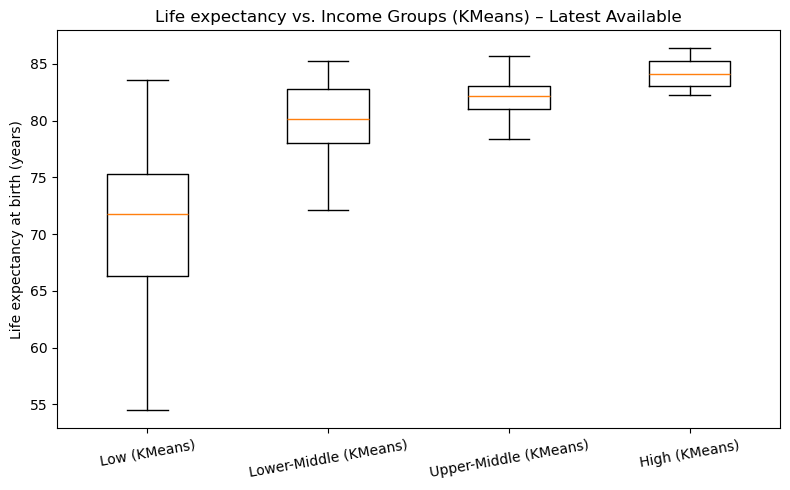

Saved: C:\Users\musta\udemy_ML\Machine Learning\ytu_datath\figures\s2_life_expectancy_box.png


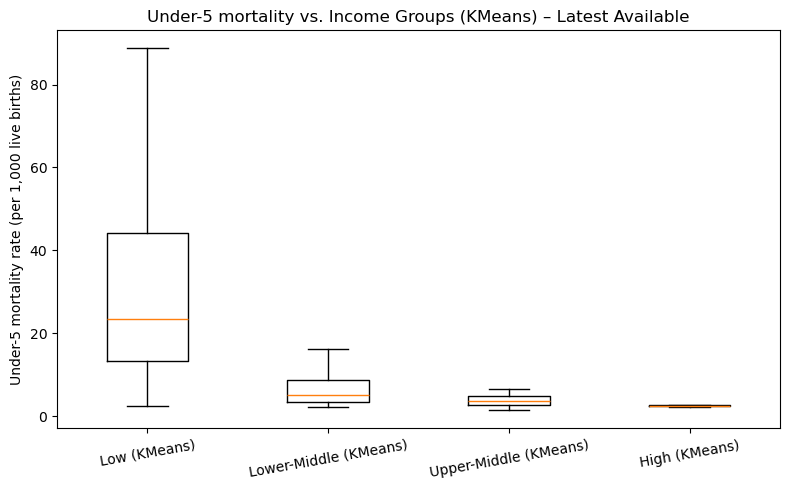

Saved: C:\Users\musta\udemy_ML\Machine Learning\ytu_datath\figures\s2_under5_mortality_box.png


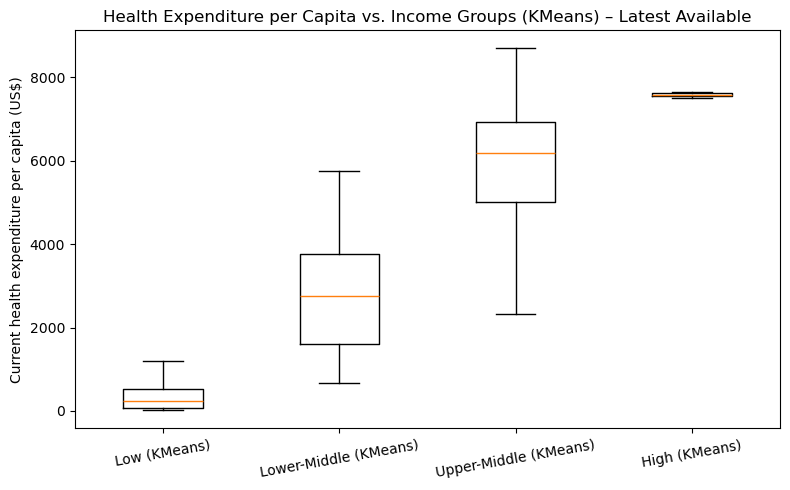

Saved: C:\Users\musta\udemy_ML\Machine Learning\ytu_datath\figures\s3_chexp_percap_box.png


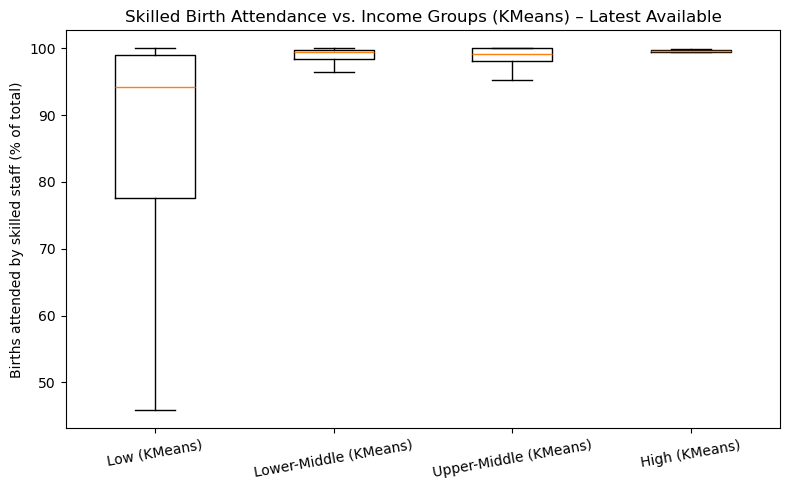

Saved: C:\Users\musta\udemy_ML\Machine Learning\ytu_datath\figures\s3_skilled_birth_box.png


In [12]:

# ==================================
# 5) Görselleştirmeler – Boxplot'lar (Slayt 2 ve 3 için)
# ==================================
import matplotlib.pyplot as plt

def boxplot_by_group(df, indicator_code, title, filename):
    tmp = df[df['Indicator Code']==indicator_code].copy()
    tmp = tmp.dropna(subset=['Value','kmeans_income_group_name'])
    order = ["Low (KMeans)", "Lower-Middle (KMeans)", "Upper-Middle (KMeans)", "High (KMeans)"]

    data = [tmp.loc[tmp['kmeans_income_group_name']==grp, 'Value'].values for grp in order]
    plt.figure(figsize=(8,5))
    plt.boxplot(data, labels=order, showfliers=False)
    plt.title(title)
    plt.ylabel(indicator_map[indicator_code])
    plt.xticks(rotation=10)
    plt.tight_layout()
    outpath = Path(FIG_DIR) / filename
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", outpath)

# Slayt 2 – Health outcomes: Life expectancy & Under-5 mortality
boxplot_by_group(latest_by_country, "SP.DYN.LE00.IN",
                 "Life expectancy vs. Income Groups (KMeans) – Latest Available",
                 "s2_life_expectancy_box.png")

boxplot_by_group(latest_by_country, "SH.DYN.MORT",
                 "Under-5 mortality vs. Income Groups (KMeans) – Latest Available",
                 "s2_under5_mortality_box.png")

# Slayt 3 – Potential drivers: Health expenditure per capita & Skilled birth attendance
boxplot_by_group(latest_by_country, "SH.XPD.CHEX.PC.CD",
                 "Health Expenditure per Capita vs. Income Groups (KMeans) – Latest Available",
                 "s3_chexp_percap_box.png")

boxplot_by_group(latest_by_country, "SH.STA.BRTC.ZS",
                 "Skilled Birth Attendance vs. Income Groups (KMeans) – Latest Available",
                 "s3_skilled_birth_box.png")


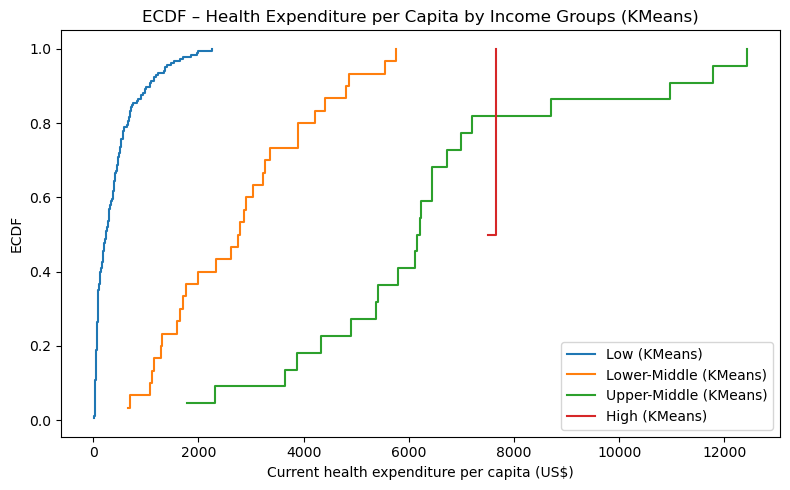

Saved: C:\Users\musta\udemy_ML\Machine Learning\ytu_datath\figures\ecdf_chexp_percap.png


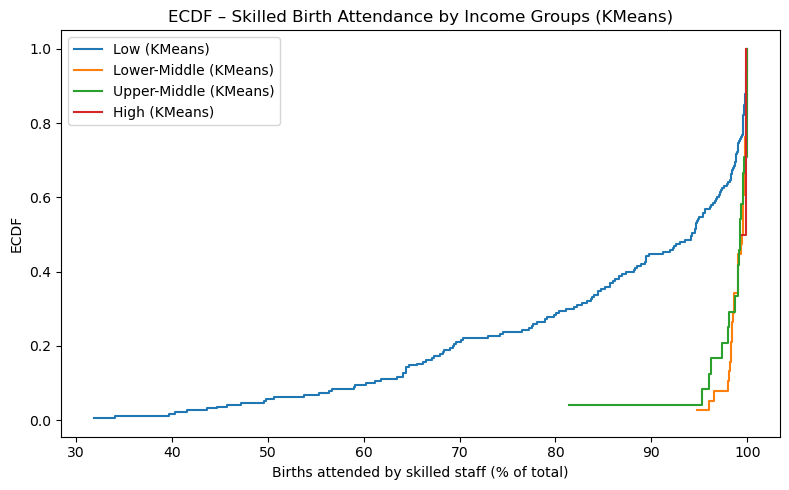

Saved: C:\Users\musta\udemy_ML\Machine Learning\ytu_datath\figures\ecdf_skilled_birth.png


In [13]:

# ==================================
# 6) ECDF Grafikleri (opsiyonel destekleyici)
# ==================================
def ecdf(values):
    values = np.sort(values[~np.isnan(values)])
    n = values.size
    y = np.arange(1, n+1) / n if n>0 else np.array([])
    return values, y

def ecdf_by_group(df, indicator_code, title, filename):
    tmp = df[df['Indicator Code']==indicator_code].copy()
    tmp = tmp.dropna(subset=['Value','kmeans_income_group_name'])
    order = ["Low (KMeans)", "Lower-Middle (KMeans)", "Upper-Middle (KMeans)", "High (KMeans)"]

    plt.figure(figsize=(8,5))
    for grp in order:
        vals = tmp.loc[tmp['kmeans_income_group_name']==grp, 'Value'].astype(float).values
        x, y = ecdf(vals)
        plt.step(x, y, where='post', label=grp)
    plt.title(title)
    plt.xlabel(indicator_map[indicator_code])
    plt.ylabel("ECDF")
    plt.legend()
    plt.tight_layout()
    outpath = Path(FIG_DIR) / filename
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", outpath)

# Örnek ECDF'ler
ecdf_by_group(latest_by_country, "SH.XPD.CHEX.PC.CD",
              "ECDF – Health Expenditure per Capita by Income Groups (KMeans)",
              "ecdf_chexp_percap.png")

ecdf_by_group(latest_by_country, "SH.STA.BRTC.ZS",
              "ECDF – Skilled Birth Attendance by Income Groups (KMeans)",
              "ecdf_skilled_birth.png")


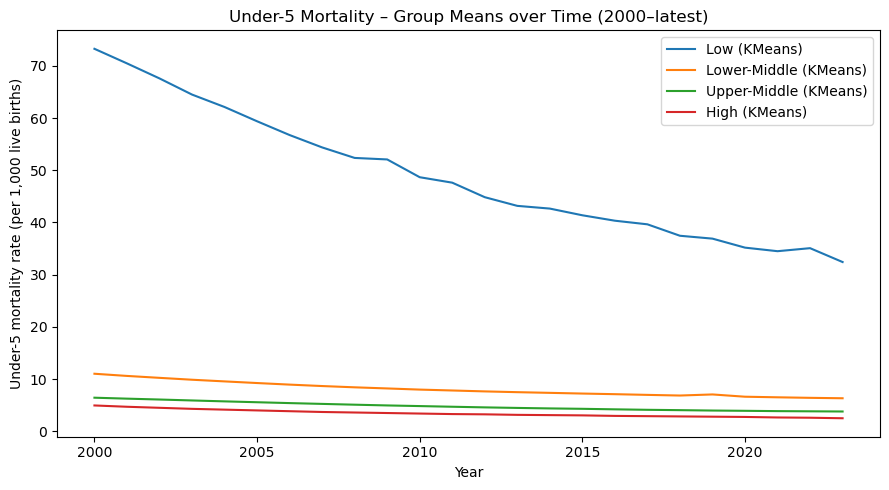

Saved: C:\Users\musta\udemy_ML\Machine Learning\ytu_datath\figures\s4_under5_mortality_timeseries.png


In [14]:

# ==================================
# 7) Zaman Serisi – Under-5 Mortality (2000–Son)
# ==================================
u5 = focus_k[focus_k['Indicator Code']=="SH.DYN.MORT"].copy()
u5 = u5[u5['Year']>=2000]
grp_year = (u5.groupby(['kmeans_income_group_name','Year'])['Value']
              .mean()
              .reset_index()
              .sort_values(['kmeans_income_group_name','Year']))

plt.figure(figsize=(9,5))
for grp in ["Low (KMeans)","Lower-Middle (KMeans)","Upper-Middle (KMeans)","High (KMeans)"]:
    sub = grp_year[grp_year['kmeans_income_group_name']==grp]
    plt.plot(sub['Year'], sub['Value'], label=grp)
plt.title("Under-5 Mortality – Group Means over Time (2000–latest)")
plt.xlabel("Year")
plt.ylabel(indicator_map["SH.DYN.MORT"])
plt.legend()
plt.tight_layout()
outpath = Path(FIG_DIR) / "s4_under5_mortality_timeseries.png"
plt.savefig(outpath, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", outpath)



## 8) Slaytlar İçin Kısa Mesajlar (Notlar)

- **Slayt 1 (Giriş & Yöntem):** Ülkeler, 2000+ döneme göre *kişi başı GSYİH ortalaması* üzerinden **K-Means** ile 4 kümeye ayrıldı. Ardından sağlık göstergeleri bu gruplar arasında karşılaştırıldı.
- **Slayt 2 (Sağlık Sonuçları):** Yaşam süresi yüksek gelire doğru artarken; 5 yaş altı ölüm oranı düşük gelirde belirgin şekilde daha yüksek.
- **Slayt 3 (Olası Nedenler):** Kişi başına sağlık harcaması ve eğitimli personel ile doğum oranı gelirle birlikte artıyor; bu iki faktör sağlık sonuçlarındaki farkların önemli belirleyicileri olabilir.
- **Slayt 4 (Zaman Serisi):** 2000 sonrası tüm gruplarda 5 yaş altı ölüm oranı düşüyor; ancak düşük gelir grubu ile diğerleri arasındaki fark **tam kapanmış değil**.

> Not: K-Means grupları, resmi Dünya Bankası `Income Group` sınıflamasından farklıdır; buna rağmen **benzer bir sıralama** gözlenir. Sunumda bu ayrımı net ifade edin.
